# **Build a Dataset Class for Horse Breeds**

https://www.kaggle.com/datasets/olgabelitskaya/horse-breeds

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")

print("Path to dataset files:", path)

100%|██████████| 82.0M/82.0M [00:00<00:00, 283MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27


In [2]:
import os
import tarfile
import matplotlib.pyplot as plt
import numpy as np
import requests
import scipy
from PIL import Image
from torch.utils.data import Dataset, Subset, random_split, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import torch

### Split the data into train val, and test set (starified)

In [3]:
def stratified_splits(root_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):

    image_paths = []
    labels = []

   
    for root, dirs, files in os.walk(root_dir):
        for filename in files:
            
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                
               
                parts = filename.split('_')
                
                
                if len(parts) > 1:
                    label = parts[0]
                    
                    
                    full_path = os.path.join(root, filename)
                    image_paths.append(full_path)
                    labels.append(label)

    print(f"Total images found: {len(image_paths)}")

    
    X_train, X_temp, y_train, y_temp = train_test_split(
        image_paths, 
        labels, 
        test_size=(1 - train_ratio), 
        stratify=labels, 
        random_state=seed
    )

    
    relative_test_size = test_ratio / (val_ratio + test_ratio)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, 
        y_temp, 
        test_size=relative_test_size, 
        stratify=y_temp, 
        random_state=seed
    )

    print(f"Data Split Summary:")
    print(f"Train: {len(X_train)} images")
    print(f"Val:   {len(X_val)} images")
    print(f"Test:  {len(X_test)} images")

    return X_train, X_val, X_test, y_train, y_val, y_test

### Dataset Class

In [4]:
class HorseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
        # This maps "01" -> 0, "02" -> 1, ..., "07" -> 6
        self.breed_to_idx = {f"{i:02d}": i-1 for i in range(1, 8)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_str = self.labels[idx]
        
        
        image = Image.open(img_path).convert("RGB") 
        
        if self.transform:
            image = self.transform(image)
            
        # Map the string label (e.g., "01") to an integer (0)
        label = self.breed_to_idx[label_str]
        
        return image, torch.tensor(label, dtype=torch.long)

### Transforms

In [5]:
mean = [0.485, 0.456, 0.406]

std = [0.229, 0.224, 0.225]

from torchvision import transforms


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),      
    transforms.RandomRotation(degrees=15),       
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

### Create Dataloader objects

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_splits(path)

train_dataset = HorseDataset(X_train, y_train, transform=train_transforms)
val_dataset = HorseDataset(X_val, y_val, transform=test_transforms)
test_dataset = HorseDataset(X_test, y_test, transform=test_transforms)


batch_size = 32

train_dataloader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

test_dataloader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

print(f"Successfully created Dataloaders.")
print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_dataloader)}")

Total images found: 670
Data Split Summary:
Train: 468 images
Val:   101 images
Test:  101 images
Successfully created Dataloaders.
Batch size: 32
Number of training batches: 15


In [38]:

from torch.utils.data import WeightedRandomSampler

print(" extracting labels from  dataset")
targets = []


for _, label in train_dataset:
    targets.append(label)

targets = np.array(targets)
print(f"Extraction  {len(targets)} labels.")

 extracting labels from  dataset
Extraction  468 labels.


In [ ]:

class_counts = np.bincount(targets)

class_weights = 1. / class_counts


sample_weights = [class_weights[t] for t in targets]

In [40]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


train_dataloader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=32, 
    sampler=sampler, 
    num_workers=2
)

print("Oversampling is  active") 

Oversampling is  active


In [41]:
images, labels = next(iter(train_dataloader))
print(f"Labels in the first batch: {labels.tolist()}")

Labels in the first batch: [1, 2, 3, 0, 5, 6, 0, 6, 2, 6, 4, 3, 1, 6, 2, 5, 6, 0, 1, 3, 1, 5, 4, 1, 5, 3, 6, 5, 3, 3, 1, 4]


#### Display some images

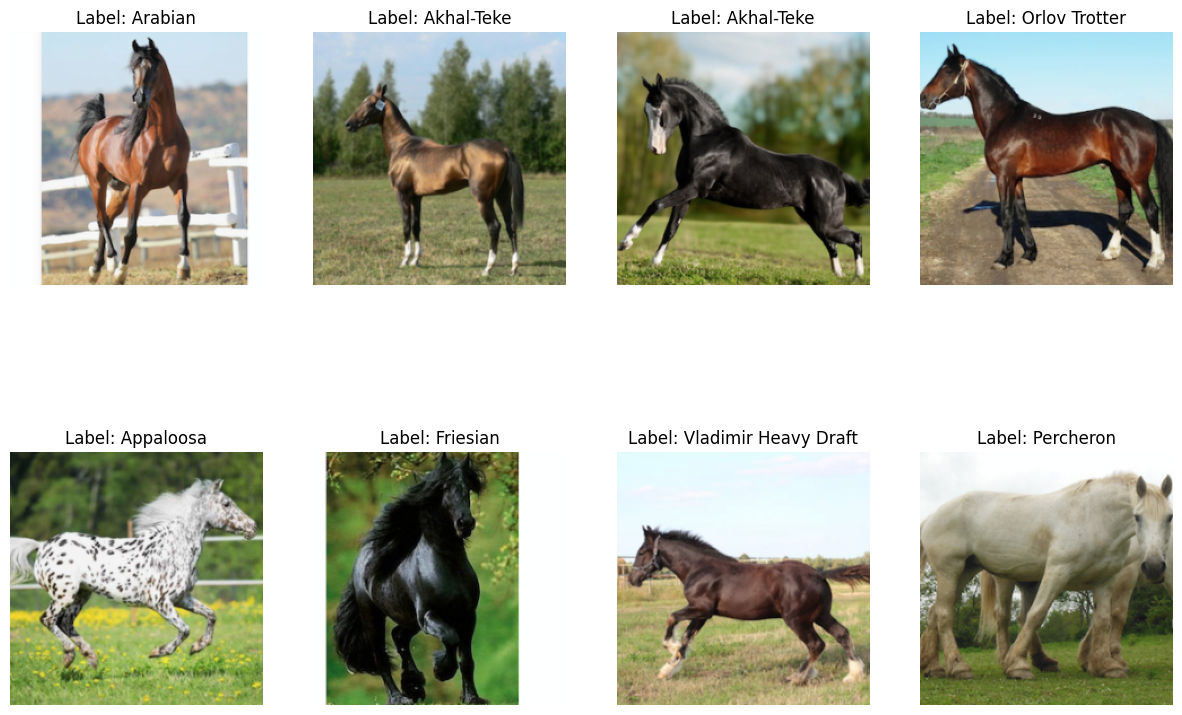

In [42]:
def show_batch(test_dataloader, breed_map):
   
    images, labels = next(iter(test_dataloader))
    
    
    plt.figure(figsize=(15, 10))
    
   
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        
        
        img = images[i].numpy().transpose((1, 2, 0))
        
      
        img = std * img + mean
        img = np.clip(img, 0, 1) 
        
        
        label_idx = labels[i].item()
        breed_code = f"{label_idx + 1:02d}"
        breed_name = breed_map.get(breed_code, "Unknown")
        
        plt.imshow(img)
        plt.title(f"Label: {breed_name}")
        plt.axis('off')


breeds_dict = {
    "01": "Akhal-Teke", "02": "Appaloosa", "03": "Orlov Trotter",
    "04": "Vladimir Heavy Draft", "05": "Percheron", "06": "Arabian", "07": "Friesian"
}


show_batch(test_dataloader, breeds_dict)
plt.show()

### Define Model 

In [43]:
import torch.nn as nn
from torchvision import models

def create_model(num_classes=7):
    
    model = models.resnet18(weights='IMAGENET1K_V1')

    num_features = model.fc.in_features
    
    model.fc = nn.Linear(num_features, num_classes)
    
    return model


model = create_model(num_classes=7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model defined and moved to: {device}")

Model defined and moved to: cuda


### define Loss and Optimizer

In [52]:
import torch.optim as optim
import torch.nn as nn


loss_function = nn.CrossEntropyLoss()


optimizer = optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

print("Loss function and Optimizer are defined.")

Loss function and Optimizer are defined.


#### Build one_epoch_training function loop 

In [51]:
def train_one_epoch(model, dataloader, loss_function, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    return running_loss / len(dataloader.dataset)

current_loss = train_one_epoch(model, train_dataloader, loss_function, optimizer, device)
    


#### Build one_epoch_validation function loop 

In [53]:
from sklearn.metrics import f1_score

def validate_one_epoch(model, dataloader, loss_function, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = running_loss / len(dataloader.dataset)
    
   
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
   
    correct = (np.array(all_preds) == np.array(all_labels)).sum()
    accuracy = 100.0 * correct / len(dataloader.dataset)
    
    return avg_loss, accuracy, f1

### Combine all to train the model
it should Save the best model and track train and val loss and accuracy


In [54]:
from sklearn.metrics import f1_score
import numpy as np
import torch

def train_model(model, train_loader, val_loader, loss_function, optimizer, epochs, device):
    history = {
        'train_loss': [], 
        'train_acc': [], 
        'val_loss': [], 
        'val_acc': [], 
        'val_f1': []
    }
    best_val_loss = float('inf')
    
    print(f"Training started on {device}...")

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
        
        train_loss = running_train_loss / len(train_loader.dataset)
        train_acc = 100. * train_correct / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                v_loss = loss_function(outputs, labels)
                running_val_loss += v_loss.item() * images.size(0)
                
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_loss = running_val_loss / len(val_loader.dataset)
        val_acc = 100. * val_correct / len(val_loader.dataset)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            save_msg = "(Model Saved!)"
        else:
            save_msg = ""

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val F1: {val_f1:.4f} {save_msg}")

    return history

history = train_model(
    model=model, 
    train_loader=train_dataloader, 
    val_loader=val_dataloader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    epochs=20,          
    device=device
)

Training started on cuda...
Epoch 1/20 | Train Acc: 97.01% | Val Acc: 94.06% | Val F1: 0.9405 (Model Saved!)
Epoch 2/20 | Train Acc: 97.86% | Val Acc: 90.10% | Val F1: 0.8981 
Epoch 3/20 | Train Acc: 97.01% | Val Acc: 92.08% | Val F1: 0.9212 
Epoch 4/20 | Train Acc: 98.50% | Val Acc: 94.06% | Val F1: 0.9403 
Epoch 5/20 | Train Acc: 98.29% | Val Acc: 92.08% | Val F1: 0.9198 
Epoch 6/20 | Train Acc: 99.79% | Val Acc: 90.10% | Val F1: 0.9007 
Epoch 7/20 | Train Acc: 99.57% | Val Acc: 93.07% | Val F1: 0.9316 
Epoch 8/20 | Train Acc: 99.79% | Val Acc: 92.08% | Val F1: 0.9218 
Epoch 9/20 | Train Acc: 100.00% | Val Acc: 94.06% | Val F1: 0.9415 (Model Saved!)
Epoch 10/20 | Train Acc: 99.79% | Val Acc: 94.06% | Val F1: 0.9415 (Model Saved!)
Epoch 11/20 | Train Acc: 100.00% | Val Acc: 90.10% | Val F1: 0.9009 
Epoch 12/20 | Train Acc: 100.00% | Val Acc: 91.09% | Val F1: 0.9115 
Epoch 13/20 | Train Acc: 100.00% | Val Acc: 91.09% | Val F1: 0.9113 
Epoch 14/20 | Train Acc: 99.79% | Val Acc: 93.07% |

### test the model on test set

In [16]:
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)
model.eval()  
print("Loaded the best model weights for testing.")

Loaded the best model weights for testing.


In [57]:
test_loss = 0.0
all_preds = []
all_labels = []

model.eval() 
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = loss_function(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        
       
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


final_test_loss = test_loss / len(test_dataloader.dataset)
final_test_acc = 100 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
final_test_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"--- Final Test Results ---")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%")
print(f"Test F1-Score: {final_test_f1:.4f}")




--- Final Test Results ---
Test Loss: 0.6062
Test Accuracy: 82.18%
Test F1-Score: 0.8134


### show some predictions with the images

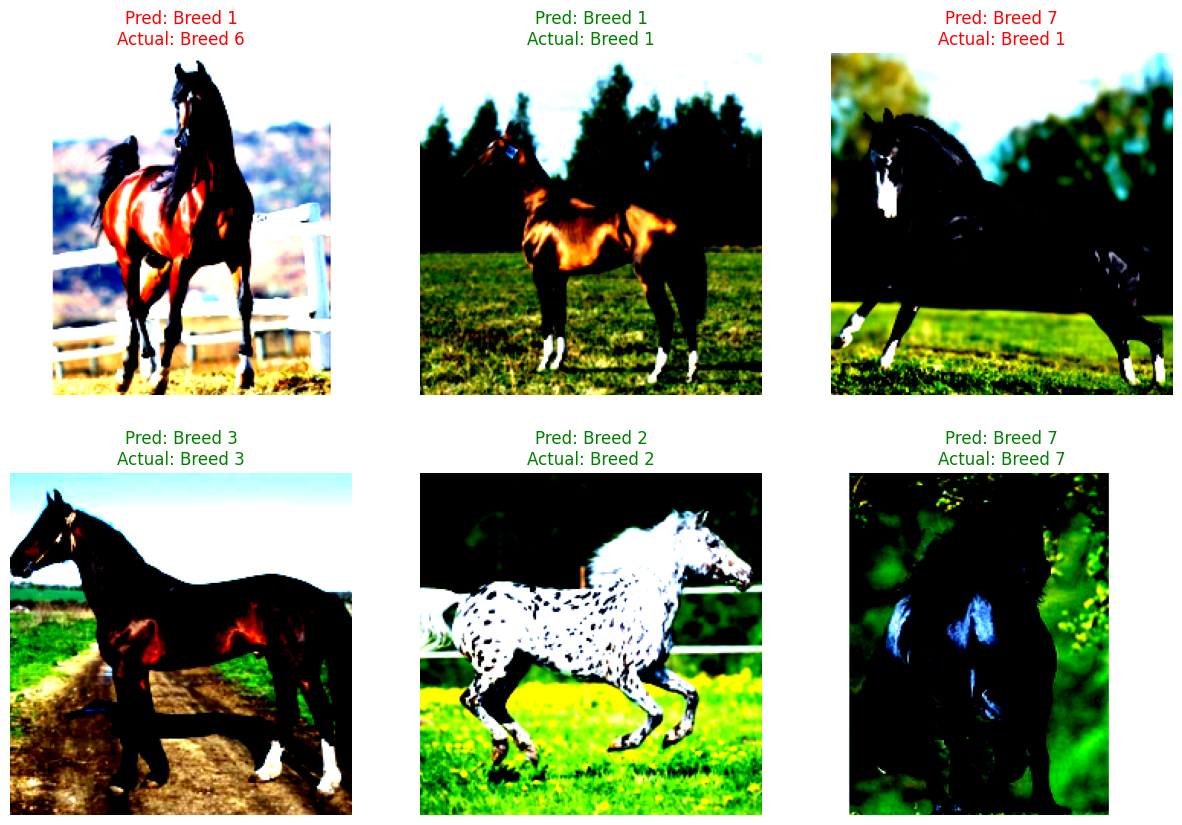

In [58]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, HorseDataset, device, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))

    class_names = ['Breed 1', 'Breed 2', 'Breed 3', 'Breed 4', 'Breed 5', 'Breed 6', 'Breed 7']

    with torch.no_grad():
        for images, labels in HorseDataset:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)
                ax.axis('off')
                
                
                color = 'green' if preds[i] == labels[i] else 'red'
                
                
                img = images.cpu().data[i].numpy().transpose((1, 2, 0))
                
                img = np.clip(img, 0, 1) 
                
                ax.set_title(f'Pred: {class_names[preds[i]]}\nActual: {class_names[labels[i]]}', color=color)
                plt.imshow(img)

                if images_so_far == num_images:
                    return

visualize_predictions(model, test_dataloader, device)
plt.show()

### Analyze the results
Is the model overfitting/underfitting?
Plot the training and validation loss/accuracy curves

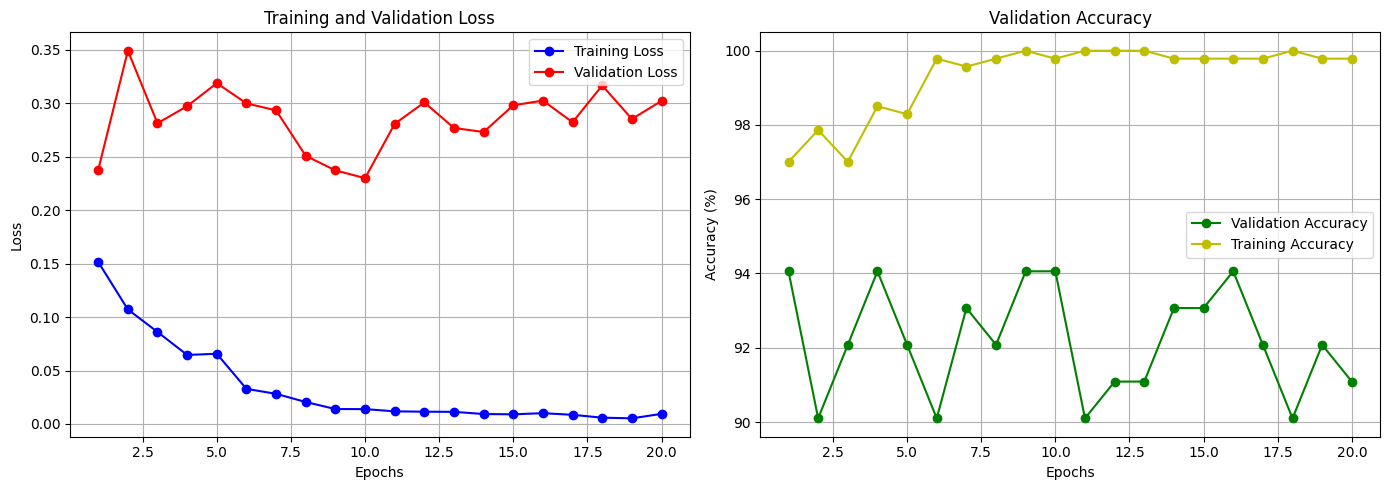

In [59]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))

  
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

   
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], 'go-', label='Validation Accuracy')
    # If you tracked train_acc, add it here:
    if 'train_acc' in history:
        plt.plot(epochs, history['train_acc'], 'yo-', label='Training Accuracy')
        
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_history(history)

### Load the model

In [60]:
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)
model.eval()  
print("Loaded the best model Done.")

Loaded the best model Done.
